# Brain Tumor MRI Dataset - Exploratory Data Analysis

## 1. Project Overview

This notebook explores the Brain Tumor MRI dataset before model development.

The analysis includes:

- Dataset overview
- Class distribution
- Sample visualization
- Image resolution analysis
- Image format analysis
- Corrupted image detection

The goal is to understand the dataset characteristics before preprocessing and model training.

## 2. Import Libraries

In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

%matplotlib inline
plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


## 3. Dataset Configuration

In [4]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

In [5]:
print(TRAIN_DIR)
print(TEST_DIR)

../data/raw/Training
../data/raw/Testing


## 4. Dataset Overview

In [6]:
classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
print(PROJECT_ROOT.resolve())
print(DATA_DIR.resolve())
print(TRAIN_DIR.resolve())
print(TEST_DIR.resolve())

/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Training
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Testing


## 5. Class Distribution

In this section, we analyze the number of MRI images in each class for both the training and testing datasets.

Understanding class distribution is important because an imbalanced dataset can lead to biased model predictions.

### Membuat Fungsi

In [8]:
def count_images(directory):
    """
    Count the number of images in each class folder.

    Parameters
    ----------
    directory : Path
        Path to Training or Testing folder.

    Returns
    -------
    dict
        Dictionary containing image counts for each class.
    """

    counts = {}

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = len(list(class_dir.glob("*")))

    return counts

### Menghitung Dataset

In [9]:
train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print(train_counts)
print(test_counts)

{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


### Membuat DataFrame

In [10]:
distribution_df = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

distribution_df

,Training,Testing
glioma,1400,400
meningioma,1400,400
notumor,1400,400
pituitary,1400,400


### Total Dataset

In [11]:
distribution_df["Total"] = (
    distribution_df["Training"] +
    distribution_df["Testing"]
)

distribution_df

,Training,Testing,Total
glioma,1400,400,1800
meningioma,1400,400,1800
notumor,1400,400,1800
pituitary,1400,400,1800


In [12]:
print(f"Total Training Images : {distribution_df['Training'].sum():,}")
print(f"Total Testing Images  : {distribution_df['Testing'].sum():,}")
print(f"Total Images          : {distribution_df['Total'].sum():,}")

Total Training Images : 5,600
Total Testing Images  : 1,600
Total Images          : 7,200


### Visualisasi

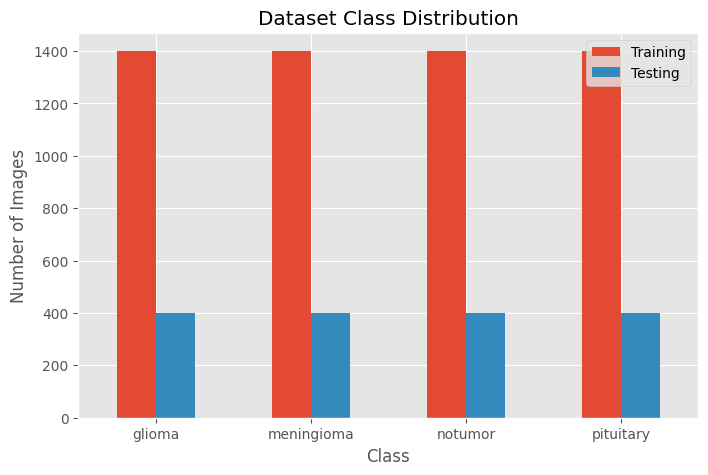

In [13]:
fig, ax = plt.subplots(figsize=(8,5))

distribution_df[["Training","Testing"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=0)

plt.show()

### Observation

The dataset is perfectly balanced.
Each class contains:

- 1,400 training images
- 400 testing images

Balanced class distributions help reduce prediction bias during model training and provide more reliable evaluation results.